# Лабораторна робота №4

## Візуалізація даних 2

**Студент:** Сапронов Анатолій  
**Група:** ФБ-45

У роботі створюється програма для інтерактивної побудови графіка гармоніки з шумом, зміни параметрів, фільтрації та порівняння результатів.

## 1. Імпорт бібліотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons

Бібліотеки імпортовано успішно.


## 2. Початкові параметри

Задаємо початкові параметри гармоніки, шуму та фільтрації.

In [2]:
amplitude = 1.0
frequency = 0.35
phase = 0.0
noise_mean = 0.0
noise_covariance = 0.16
filter_window = 25
show_noise = True

t = np.linspace(0, 10, 800)

print("Початкові параметри задано.")

Початкові параметри задано.


## 3. Реалізація функції гармоніки

Функція приймає параметри амплітуди, частоти, фази, середнього шуму, дисперсії шуму та прапорець для відображення шуму.

In [3]:
def harmonic(t, amplitude, frequency, phase, noise_mean=0.0, noise_covariance=0.0, show_noise=True, seed=42):
    clean = amplitude * np.sin(2 * np.pi * frequency * t + phase)

    rng = np.random.default_rng(seed)
    noise = rng.normal(noise_mean, np.sqrt(noise_covariance), len(t))

    if show_noise:
        noisy = clean + noise
    else:
        noisy = clean.copy()

    return clean, noisy, noise

clean_signal, noisy_signal, noise = harmonic(
    t,
    amplitude,
    frequency,
    phase,
    noise_mean,
    noise_covariance,
    show_noise
)

print("Функцію harmonic створено та виконано.")

Функцію harmonic створено та виконано.


## 4. Фільтрація зашумленого сигналу

Для фільтрації використано ковзне середнє. Воно згладжує різкі коливання шуму та дозволяє наблизити сигнал до початкової гармоніки.

In [4]:
def moving_average_filter(signal, window_size=25):
    return pd.Series(signal).rolling(
        window=window_size,
        center=True,
        min_periods=1
    ).mean().to_numpy()

filtered_signal = moving_average_filter(noisy_signal, filter_window)

print("Фільтрацію виконано.")

Фільтрацію виконано.


## 5. Побудова початкового графіка

На графіку показано чисту гармоніку, зашумлений сигнал та відфільтрований сигнал.

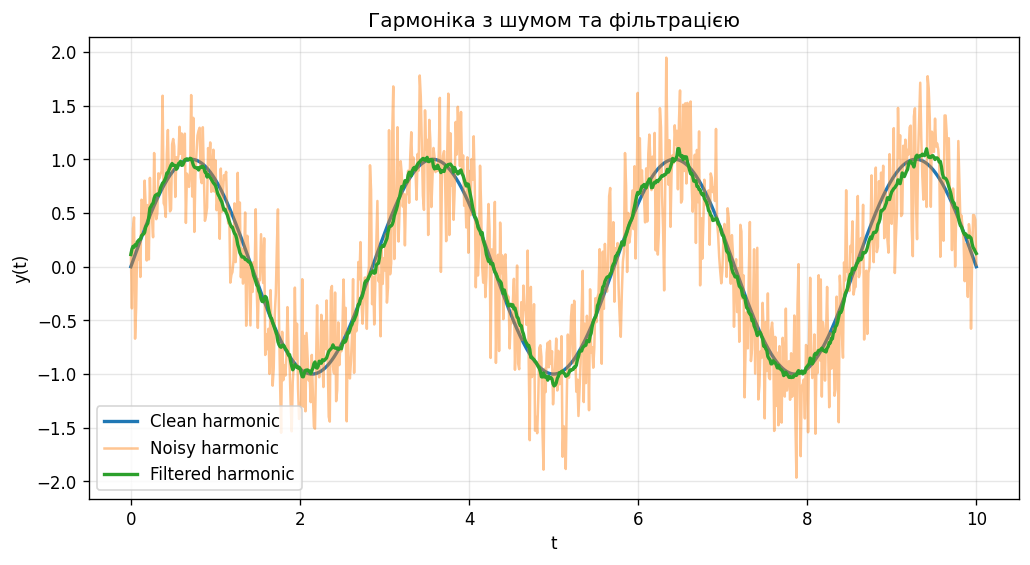

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(t, clean_signal, label="Clean harmonic", linewidth=2)
plt.plot(t, noisy_signal, label="Noisy harmonic", alpha=0.45)
plt.plot(t, filtered_signal, label="Filtered harmonic", linewidth=2)

plt.title("Гармоніка з шумом та фільтрацією")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Порівняння впливу параметрів

Перевіримо, як зміна амплітуди, частоти та фази впливає на вигляд гармоніки.

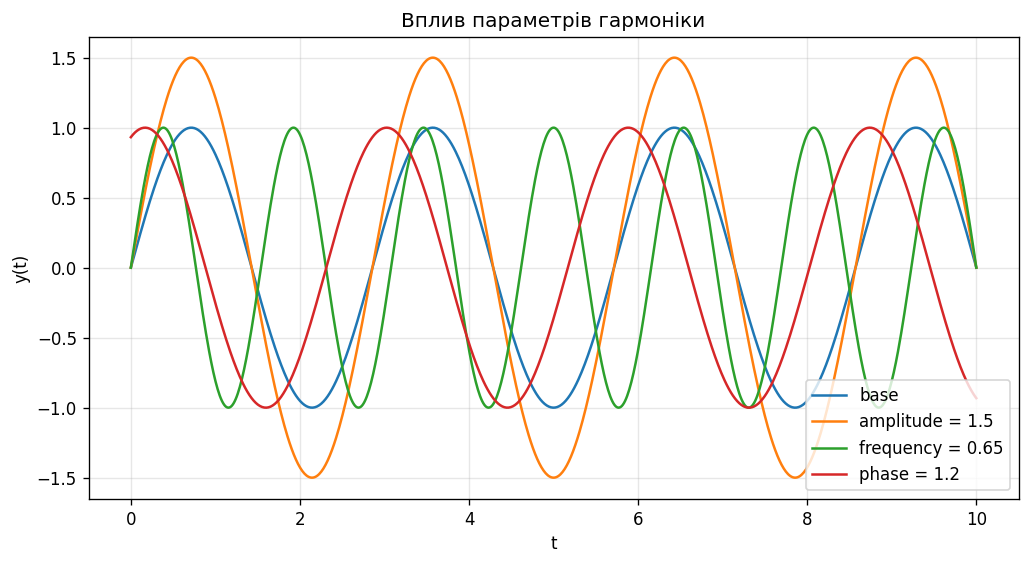

In [6]:
t2 = np.linspace(0, 10, 800)

y1 = 1.0 * np.sin(2*np.pi*0.35*t2 + 0)
y2 = 1.5 * np.sin(2*np.pi*0.35*t2 + 0)
y3 = 1.0 * np.sin(2*np.pi*0.65*t2 + 0)
y4 = 1.0 * np.sin(2*np.pi*0.35*t2 + 1.2)

plt.figure(figsize=(10, 5))
plt.plot(t2, y1, label="base")
plt.plot(t2, y2, label="amplitude = 1.5")
plt.plot(t2, y3, label="frequency = 0.65")
plt.plot(t2, y4, label="phase = 1.2")

plt.title("Вплив параметрів гармоніки")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Порівняння різних параметрів фільтрації

Чим більше вікно фільтра, тим сильніше згладжується сигнал.

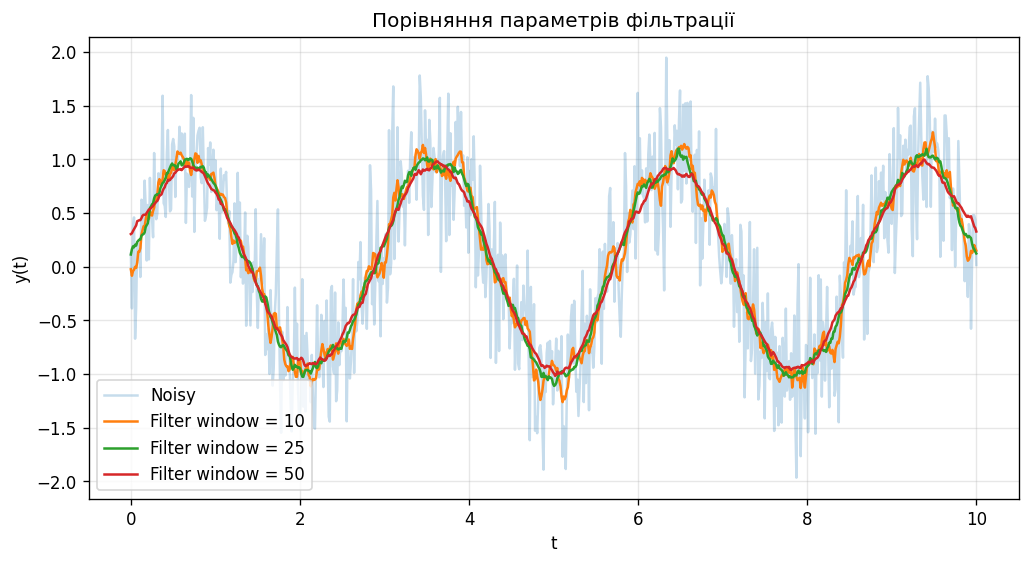

In [7]:
filtered_10 = moving_average_filter(noisy_signal, 10)
filtered_25 = moving_average_filter(noisy_signal, 25)
filtered_50 = moving_average_filter(noisy_signal, 50)

plt.figure(figsize=(10, 5))
plt.plot(t, noisy_signal, alpha=0.25, label="Noisy")
plt.plot(t, filtered_10, label="Filter window = 10")
plt.plot(t, filtered_25, label="Filter window = 25")
plt.plot(t, filtered_50, label="Filter window = 50")

plt.title("Порівняння параметрів фільтрації")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Інтерактивний інтерфейс

Нижче наведено код інтерактивного інтерфейсу з `Slider`, `Button` та `CheckButtons`. У звичайному Jupyter Notebook після запуску цього коду користувач може змінювати параметри гармоніки та шуму.

In [8]:
# Код інтерактивного інтерфейсу

fig, ax = plt.subplots(figsize=(10, 5))
plt.subplots_adjust(left=0.1, bottom=0.38)

initial_noise_seed = 42
current_noise_seed = initial_noise_seed

clean, noisy, noise = harmonic(
    t,
    amplitude,
    frequency,
    phase,
    noise_mean,
    noise_covariance,
    show_noise=True,
    seed=current_noise_seed
)

filtered = moving_average_filter(noisy, filter_window)

line_clean, = ax.plot(t, clean, label="Clean harmonic", linewidth=2)
line_noisy, = ax.plot(t, noisy, label="Noisy harmonic", alpha=0.45)
line_filtered, = ax.plot(t, filtered, label="Filtered harmonic", linewidth=2)

ax.set_title("Interactive harmonic with noise")
ax.set_xlabel("t")
ax.set_ylabel("y(t)")
ax.grid(True, alpha=0.3)
ax.legend()

ax_amp = plt.axes([0.20, 0.28, 0.55, 0.03])
ax_freq = plt.axes([0.20, 0.24, 0.55, 0.03])
ax_phase = plt.axes([0.20, 0.20, 0.55, 0.03])
ax_noise_mean = plt.axes([0.20, 0.16, 0.55, 0.03])
ax_noise_cov = plt.axes([0.20, 0.12, 0.55, 0.03])
ax_filter = plt.axes([0.20, 0.08, 0.55, 0.03])

slider_amp = Slider(ax_amp, "Amplitude", 0.1, 3.0, valinit=amplitude)
slider_freq = Slider(ax_freq, "Frequency", 0.1, 2.0, valinit=frequency)
slider_phase = Slider(ax_phase, "Phase", -np.pi, np.pi, valinit=phase)
slider_noise_mean = Slider(ax_noise_mean, "Noise Mean", -1.0, 1.0, valinit=noise_mean)
slider_noise_cov = Slider(ax_noise_cov, "Noise Covariance", 0.01, 1.0, valinit=noise_covariance)
slider_filter = Slider(ax_filter, "Filter Window", 3, 101, valinit=filter_window, valstep=2)

ax_check = plt.axes([0.80, 0.12, 0.15, 0.08])
check_noise = CheckButtons(ax_check, ["Show Noise"], [True])

ax_reset = plt.axes([0.80, 0.24, 0.12, 0.05])
button_reset = Button(ax_reset, "Reset")

def update(val=None):
    clean, noisy, noise = harmonic(
        t,
        slider_amp.val,
        slider_freq.val,
        slider_phase.val,
        slider_noise_mean.val,
        slider_noise_cov.val,
        check_noise.get_status()[0],
        seed=current_noise_seed
    )

    filtered = moving_average_filter(noisy, int(slider_filter.val))

    line_clean.set_ydata(clean)
    line_noisy.set_ydata(noisy)
    line_noisy.set_visible(check_noise.get_status()[0])
    line_filtered.set_ydata(filtered)

    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

def reset(event):
    slider_amp.reset()
    slider_freq.reset()
    slider_phase.reset()
    slider_noise_mean.reset()
    slider_noise_cov.reset()
    slider_filter.reset()

slider_amp.on_changed(update)
slider_freq.on_changed(update)
slider_phase.on_changed(update)
slider_noise_mean.on_changed(update)
slider_noise_cov.on_changed(update)
slider_filter.on_changed(update)
check_noise.on_clicked(update)
button_reset.on_clicked(reset)

print("Інтерактивний інтерфейс створено. У Jupyter Notebook можна керувати графіком через слайдери, чекбокс та кнопку Reset.")

Інтерактивний інтерфейс створено. У Jupyter Notebook можна керувати графіком через слайдери, чекбокс та кнопку Reset.


## 9. Фінальний вигляд результату

Оскільки інтерактивні слайдери не завжди відображаються у GitHub Preview, нижче додано статичний графік фінального результату.

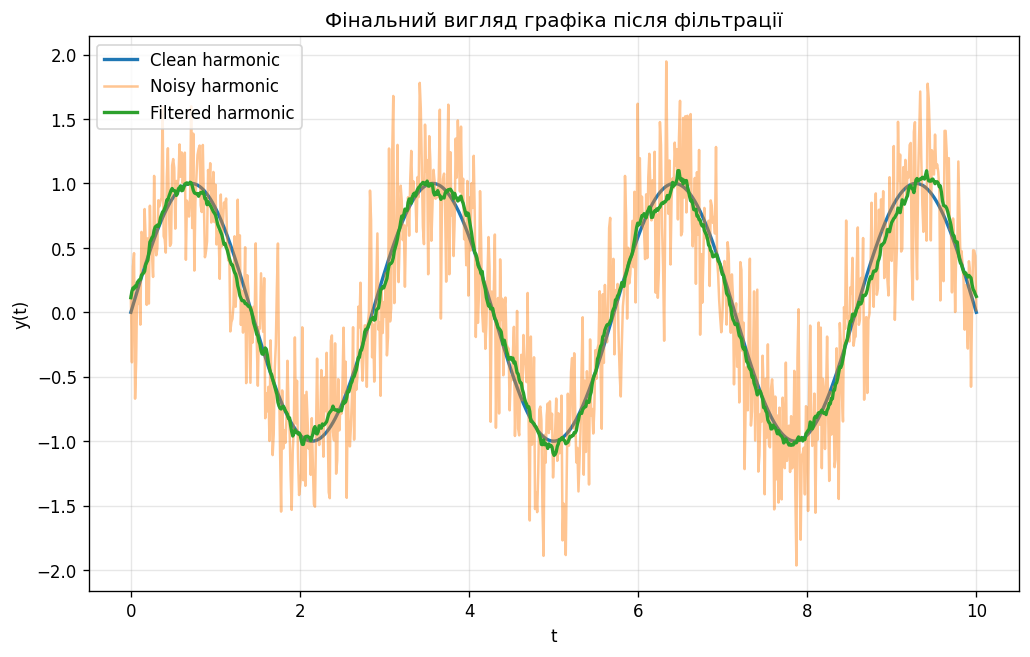

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(t, clean_signal, label="Clean harmonic", linewidth=2)
plt.plot(t, noisy_signal, label="Noisy harmonic", alpha=0.45)
plt.plot(t, filtered_signal, label="Filtered harmonic", linewidth=2)

plt.title("Фінальний вигляд графіка після фільтрації")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Інструкція користувача

1. `Amplitude` змінює висоту гармоніки.  
2. `Frequency` змінює частоту коливань.  
3. `Phase` зсуває гармоніку по осі часу.  
4. `Noise Mean` змінює середнє значення шуму.  
5. `Noise Covariance` змінює інтенсивність шуму.  
6. `Filter Window` змінює силу згладжування.  
7. `Show Noise` показує або приховує зашумлений сигнал.  
8. `Reset` повертає параметри до початкових значень.

## Висновок

У лабораторній роботі створено програму для побудови гармонічної функції з шумом, реалізовано зміну параметрів через інтерактивні елементи, додано можливість приховувати шум, виконано фільтрацію зашумленого сигналу та побудовано порівняльні графіки. 